# Neural Crest Cell Migration Dynamics

**Analysis notebook — population-level statistics for publication**

This notebook quantifies the spatial and temporal dynamics of trunk and cranial neural crest cell migration from 2D time-lapse fluorescence microscopy. Two-channel images (membrane + nucleus) were segmented and tracked in earlier pipeline stages; here, per-cell tracks are aligned to a shared biological reference point — the moment of minimum nuclear circularity — and analysed at the population level.

Three positional markers are tracked per cell:
- **Nucleus centroid** — centre-of-mass of the nuclear mask along the migration axis
- **Membrane leading edge** (`mem_front`) — anterior boundary of the cell
- **Membrane trailing edge** (`mem_back`) — posterior boundary of the cell

Comparisons are made between **trunk** and **cranial** populations, and across treatment groups (control, ROCK inhibitor, CBD).

In [1]:
# ── Path setup ──────────────────────────────────────────────────────────────
import sys
import os

# Add the repo root to sys.path so the utility package can be imported
REPO_ROOT = os.path.abspath('..')
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from utility import config

# ── Input / output paths ─────────────────────────────────────────────────────
CSV_PATH      = r'..\03-extracted_params\combined_cell_profiles.csv'
METADATA_PATH = r'metadata.csv'
OUTPUT_DIR    = r'..\05-plots'
PARAMS_DIR    = r'..\03-extracted_params'

# ── Physical units ────────────────────────────────────────────────────────────
PIXEL_SIZE_UM  = 0.368   # µm per pixel
FRAME_RATE_MIN = 3       # minutes per frame

# ── Experimental groups ───────────────────────────────────────────────────────
TRUNK_SUBJECTS   = [1, 2, 3, 4, 5, 7, 8, 31, 32, 33, 34]
CRANIAL_SUBJECTS = [23, 24, 25, 26]

# ── Plot style ────────────────────────────────────────────────────────────────
ERROR_TYPE = 'sem'   # 'sem' (standard error of mean) or 'std' (standard deviation)

In [2]:
# ── Scientific computing ──────────────────────────────────────────────────────
import pandas as pd
import numpy as np
from scipy.signal import savgol_filter
from scipy.stats import ranksums

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Optional

# Ensure text is editable as text objects in exported SVGs
matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.family']  = 'Arial'

In [3]:
def align_tracks_to_min_circularity(df):
    """
    Align each cell's spatial and temporal coordinates to its moment of minimum
    nuclear circularity (the biological reference event; see Section 1 markdown).

    Adds four columns to the returned DataFrame:
      - nuc_centroid_aligned : nucleus centroid position relative to reference (pixels)
      - mem_front_aligned    : leading-edge position relative to reference (pixels)
      - mem_back_aligned     : trailing-edge position relative to reference (pixels)
      - aligned_frame_idx    : frame index relative to reference (0 = min circularity)

    Parameters
    ----------
    df : pd.DataFrame
        Combined cell profiles table (one row per cell per frame).
        Required columns: 'sub', 'cell_idx', 'circularity_nuc', 'pos_on_track',
        'mem_front', 'mem_back', 'frame'.
    """
    df_aligned = df.copy()

    min_circ_idx = df_aligned.groupby(['sub', 'cell_idx'])['circularity_nuc'].idxmin()
    ref_df = df_aligned.loc[min_circ_idx, ['sub', 'cell_idx', 'pos_on_track', 'frame']]
    ref_df = ref_df.rename(columns={'pos_on_track': 'x0', 'frame': 'frame0'})

    df_aligned = df_aligned.merge(ref_df, on=['sub', 'cell_idx'], how='left')

    df_aligned['nuc_centroid_aligned'] = df_aligned['pos_on_track'] - df_aligned['x0']
    df_aligned['mem_front_aligned']    = df_aligned['mem_front']    - df_aligned['x0']
    df_aligned['mem_back_aligned']     = df_aligned['mem_back']     - df_aligned['x0']
    df_aligned['aligned_frame_idx']    = df_aligned['frame']        - df_aligned['frame0']

    df_aligned = df_aligned.drop(columns=['x0', 'frame0'])
    return df_aligned


def plot_var_dynamics(df, var='pos_on_track_aligned', duration=10, ax=None,
                      color='#1f77b4', error='std'):
    """
    Plot mean ± error ribbon of a variable over the aligned time window.

    Parameters
    ----------
    df       : pd.DataFrame  Cell tracks with 'aligned_frame_idx' and `var` columns.
    var      : str           Column to plot on the y-axis.
    duration : int           Half-window in frames (plots from -duration to +duration).
    ax       : plt.Axes      Target axes; creates new figure if None.
    color    : str           Line and ribbon colour.
    error    : str           'std' for standard deviation or 'sem' for standard error.
    """
    df_window = df[(df['aligned_frame_idx'] >= -duration) &
                   (df['aligned_frame_idx'] <=  duration)]

    grouped   = df_window.groupby('aligned_frame_idx')[var]
    mean_vals = grouped.mean()
    err_vals  = grouped.std() if error == 'std' else grouped.std() / grouped.count() ** 0.5
    frames    = mean_vals.index

    if ax is None:
        ax = plt.gca()

    ax.plot(frames, mean_vals, color=color, linewidth=2.5, label=var)
    ax.fill_between(frames, mean_vals - err_vals, mean_vals + err_vals,
                    color=color, alpha=0.2)
    ax.axvline(x=0, color='red', linestyle='--', alpha=0.8)
    ax.set_xlabel('Aligned frame (0 = minimum circularity)')
    ax.set_ylabel(var)
    ax.set_xlim(-duration, duration)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend()
    plt.tight_layout()


def plot_measurement_traces(df: pd.DataFrame, var: str = 'speed_nuc',
                            duration: int = 50, ax: Optional[plt.Axes] = None,
                            **kwargs) -> plt.Axes:
    """
    Spaghetti plot: one line per cell, aligned to the reference event.

    Parameters
    ----------
    df       : pd.DataFrame  Must contain 'sub', 'cell_idx', 'aligned_frame_idx', and `var`.
    var      : str           Column to plot on the y-axis.
    duration : int           Half-window in frames.
    ax       : plt.Axes      Target axes; creates new figure if None.
    **kwargs                 Passed to ax.plot() (e.g. color, alpha, lw).
    """
    required_cols = ['sub', 'cell_idx', 'aligned_frame_idx', var]
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Required column '{col}' not found in DataFrame.")

    plot_df = df[(df['aligned_frame_idx'] >= -duration) &
                 (df['aligned_frame_idx'] <=  duration)].copy()

    if plot_df.empty:
        print(f"Warning: no data in window [-{duration}, {duration}]")
        return ax

    if ax is None:
        _, ax = plt.subplots(figsize=(8, 5))

    kwargs.setdefault('alpha', 0.3)
    kwargs.setdefault('color', 'gray')

    for (_, _), trace in plot_df.groupby(['sub', 'cell_idx']):
        ax.plot(trace.sort_values('aligned_frame_idx')['aligned_frame_idx'],
                trace.sort_values('aligned_frame_idx')[var], **kwargs)

    ax.axvline(0, color='black', linestyle='--', alpha=0.5, label='Alignment point')
    ax.set_xlabel('Aligned frame index')
    ax.set_ylabel(var.replace('_', ' ').title())
    ax.set_xlim(-duration, duration)
    ax.grid(True, linestyle=':', alpha=0.6)
    return ax


def add_robust_1d_speed(df, target_col, window_size=11, polyorder=2, absolute=True):
    """
    Compute instantaneous 1-D velocity via Savitzky-Golay differentiation.

    A Savitzky-Golay filter fits a polynomial locally and analytically
    differentiates it, producing a smoothed derivative that is less sensitive
    to frame-to-frame noise than a simple finite difference.

    Result is stored in a new column named ``speed_{target_col}``.
    Units: pixels per frame (multiply by PIXEL_SIZE_UM / FRAME_RATE_MIN for µm/min).

    Parameters
    ----------
    df          : pd.DataFrame  Must contain 'sub', 'cell_idx', 'frame', and `target_col`.
    target_col  : str           Column to differentiate.
    window_size : int           Filter window length (must be odd, ≥ 3).
    polyorder   : int           Polynomial order for the local fit.
    absolute    : bool          If True, return speed (|velocity|); False returns signed velocity.
    """
    new_col = f"speed_{target_col}"
    df[new_col] = np.nan

    for (_, _), group in df.groupby(['sub', 'cell_idx']):
        if len(group) < 3:
            continue
        group = group.sort_values('frame')
        w = window_size
        if len(group) <= w:
            w = len(group) if len(group) % 2 != 0 else len(group) - 1
        if w < 3:
            continue
        deriv = savgol_filter(group[target_col], window_length=w,
                              polyorder=polyorder, deriv=1)
        if absolute:
            deriv = np.abs(deriv)
        df.loc[group.index, new_col] = deriv

    return df


def calculate_corr(df, col1, col2, duration=30):
    """
    Pearson correlation between two variables for each cell within the aligned window.

    Parameters
    ----------
    df       : pd.DataFrame  Must contain 'sub', 'cell_idx', 'aligned_frame_idx', col1, col2.
    col1     : str           First variable.
    col2     : str           Second variable.
    duration : int           Half-window in frames.

    Returns
    -------
    pd.DataFrame  Columns: ['sub', 'cell_idx', 'cross_corr']
    """
    df_window = df[(df['aligned_frame_idx'] >= -duration) &
                   (df['aligned_frame_idx'] <=  duration)].copy()

    results = (
        df_window
        .groupby(['sub', 'cell_idx'])[[col1, col2]]
        .apply(lambda g: g[col1].corr(g[col2]) if len(g) >= 3 else np.nan)
    )

    results_df = results.reset_index()
    results_df.columns = ['sub', 'cell_idx', 'cross_corr']
    return results_df

## 1  Data loading and track alignment

### Input data
`combined_cell_profiles.csv` contains one row per cell per frame. Each row records morphological features (circularity, area, aspect ratio) and the 1-D position of the nucleus centroid, leading edge, and trailing edge along the migration axis, extracted from segmentation masks produced in the preceding pipeline stages.

### Alignment convention
Individual cells begin migrating at different absolute times. To compare dynamics across the population, each cell's time axis is shifted so that **frame 0 corresponds to the moment of minimum nuclear circularity**. Minimum circularity marks the transition from a rounded, pre-migratory morphology to an elongated, actively migrating one, and therefore serves as a proxy for migration initiation. Spatial positions are simultaneously re-zeroed to the nucleus centroid at that reference frame.

### Speed estimation
Instantaneous velocity is computed as the first derivative of each aligned position time-series using a **Savitzky-Golay filter** (window = 11 frames, polynomial order = 2). This approach fits a local polynomial and differentiates analytically, reducing noise amplification compared to simple finite differences. The derivative is left signed so that the direction of movement is preserved (positive = anterior, negative = posterior).

In [4]:
df = pd.read_csv(CSV_PATH)
aligned_df = align_tracks_to_min_circularity(df)

# Compute signed velocities for the three positional markers
aligned_df = add_robust_1d_speed(aligned_df, 'nuc_centroid_aligned', window_size=11, polyorder=2, absolute=False)
aligned_df = add_robust_1d_speed(aligned_df, 'mem_front_aligned',    window_size=11, polyorder=2, absolute=False)
aligned_df = add_robust_1d_speed(aligned_df, 'mem_back_aligned',     window_size=11, polyorder=2, absolute=False)

print(f"Loaded {df['sub'].nunique()} subjects, {df.groupby(['sub','cell_idx']).ngroups} cell tracks, {len(df)} total rows.")

Loaded 34 subjects, 166 cell tracks, 13296 total rows.


## 2  Population-level migration dynamics

The figure below shows mean ± SEM of position (top row) and speed (bottom row) for the trunk (left) and cranial (right) neural crest populations, each aligned to t = 0 (minimum circularity).

**Colour code:**
| Colour | Marker |
|--------|--------|
| Blue   | Nucleus centroid |
| Orange | Membrane trailing edge (posterior) |
| Green  | Membrane leading edge (anterior) |

The **red dashed line** marks the alignment point (t = 0). Axes are converted from pixels/frames to µm and minutes using the acquisition parameters defined in the configuration cell.

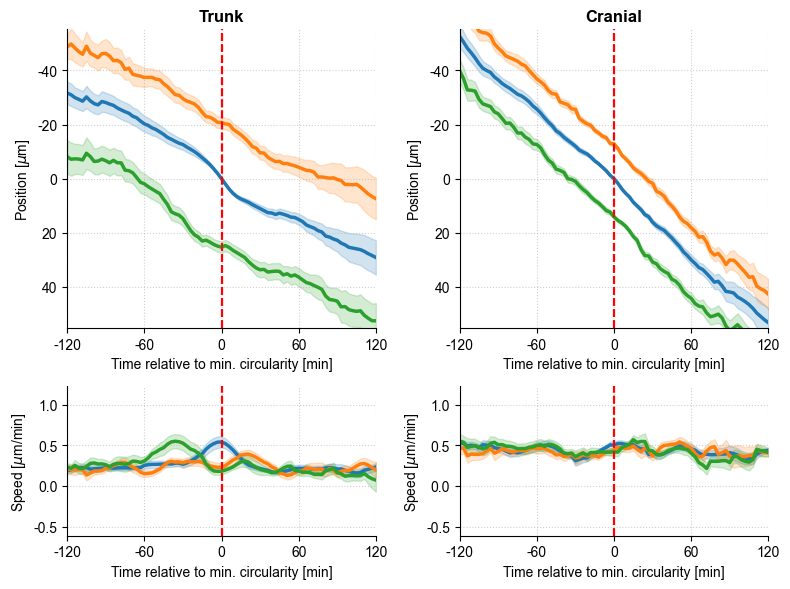

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(8, 6), height_ratios=[2, 1])

aligned_df_trunk   = aligned_df[aligned_df['sub'].isin(TRUNK_SUBJECTS)]
aligned_df_cranial = aligned_df[aligned_df['sub'].isin(CRANIAL_SUBJECTS)]

for i, (pop_df, body_part) in enumerate(
    zip([aligned_df_trunk, aligned_df_cranial], ['Trunk', 'Cranial'])
):
    # ── Position panel ──────────────────────────────────────────────────────
    plot_var_dynamics(pop_df, var='nuc_centroid_aligned', duration=40,
                      ax=axes[0, i], color='#1f77b4', error=ERROR_TYPE)
    plot_var_dynamics(pop_df, var='mem_back_aligned',     duration=40,
                      ax=axes[0, i], color='#ff7f0e', error=ERROR_TYPE)
    plot_var_dynamics(pop_df, var='mem_front_aligned',    duration=40,
                      ax=axes[0, i], color='#2ca02c', error=ERROR_TYPE)

    axes[0, i].set_title(body_part, fontweight='bold')
    axes[0, i].legend().set_visible(False)
    axes[0, i].set_ylim(150, -150)   # inverted: anterior is up
    axes[0, i].set_xticks(np.array([-40, -20, 0, 20, 40]))
    axes[0, i].set_xticklabels(np.array([-40, -20, 0, 20, 40]) * FRAME_RATE_MIN)
    axes[0, i].set_yticks(np.array([-40, -20, 0, 20, 40]) / PIXEL_SIZE_UM)
    axes[0, i].set_yticklabels(np.array([-40, -20, 0, 20, 40]))
    axes[0, i].set_ylabel(r'Position [$\mu$m]')
    axes[0, i].set_xlabel('Time relative to min. circularity [min]')

    # ── Speed panel ─────────────────────────────────────────────────────────
    plot_var_dynamics(pop_df, var='speed_nuc_centroid_aligned', duration=40,
                      ax=axes[1, i], color='#1f77b4', error=ERROR_TYPE)
    plot_var_dynamics(pop_df, var='speed_mem_back_aligned',     duration=40,
                      ax=axes[1, i], color='#ff7f0e', error=ERROR_TYPE)
    plot_var_dynamics(pop_df, var='speed_mem_front_aligned',    duration=40,
                      ax=axes[1, i], color='#2ca02c', error=ERROR_TYPE)

    axes[1, i].legend().set_visible(False)
    axes[1, i].set_xticks(np.array([-40, -20, 0, 20, 40]))
    axes[1, i].set_xticklabels(np.array([-40, -20, 0, 20, 40]) * FRAME_RATE_MIN)
    axes[1, i].set_yticks(np.arange(-1, 2, 0.5) / (PIXEL_SIZE_UM / FRAME_RATE_MIN))
    axes[1, i].set_yticklabels(np.arange(-1, 2, 0.5))
    axes[1, i].set_ylim(-5, 10)
    axes[1, i].set_ylabel(r'Speed [$\mu$m/min]')
    axes[1, i].set_xlabel('Time relative to min. circularity [min]')

sns.despine()
plt.tight_layout()

fig.savefig(os.path.join(OUTPUT_DIR, f'aligned_dynamics_{ERROR_TYPE}.svg'))
fig.savefig(os.path.join(OUTPUT_DIR, f'aligned_dynamics_{ERROR_TYPE}.png'), dpi=300)
plt.show()

In [6]:
# Export aligned table for use in downstream analyses
aligned_df.to_csv(os.path.join(PARAMS_DIR, 'aligned_cell_profiles.csv'), index=False)
print("Saved aligned_cell_profiles.csv")

Saved aligned_cell_profiles.csv


## 3  Nucleus–trailing-edge speed correlation

To assess whether nuclear translocation and trailing-edge retraction are mechanistically coupled, we compute the **Pearson correlation** between nucleus speed and trailing-edge speed for each cell individually, using the 20-frame window centred on the alignment point (t ∈ [−20, +20] frames, i.e. ±60 min).

- A **positive correlation** indicates that the nucleus and trailing edge move in concert — the nucleus advances as the trailing edge retracts, consistent with coordinated cell body translocation.
- A **near-zero or negative correlation** suggests that the two events are temporally decoupled.

Per-cell correlation values are visualised as strip plots, grouped by subject and colour-coded by treatment (control, ROCK inhibitor, CBD).

In [7]:
corr_df = calculate_corr(aligned_df, 'speed_nuc_centroid_aligned', 'speed_mem_back_aligned', duration=20)

metadata = pd.read_csv(METADATA_PATH)
corr_df  = corr_df.merge(metadata, on='sub', how='left')

corr_df.to_csv(os.path.join(PARAMS_DIR, 'cross_correlation_mem_back.csv'), index=False)
print(f"Correlation computed for {len(corr_df)} cells across {corr_df['sub'].nunique()} subjects.")

Correlation computed for 166 cells across 34 subjects.


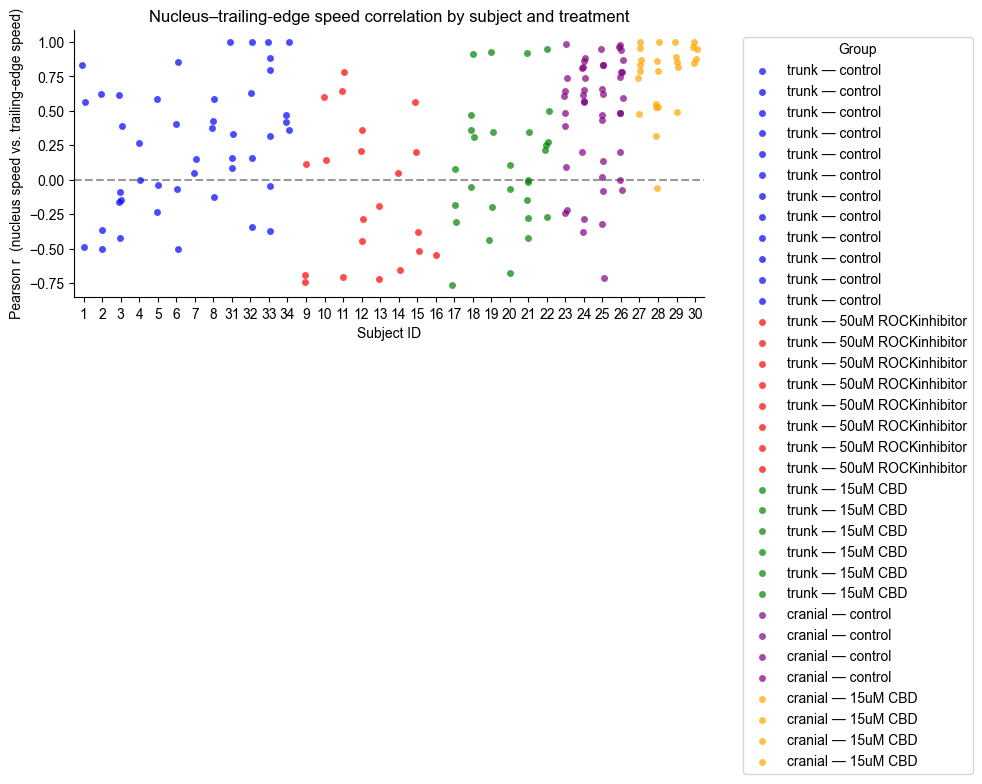

In [8]:
def plot_stripplot(df, bodyPart='trunk', treatment='control', ax=None, color=None):
    """Strip plot of per-cell correlation values for one body-part × treatment group."""
    df_ = df[
        (df['treatment'] == treatment) &
        (df['bodyPart']  == bodyPart)
    ].reset_index(drop=True)

    sns.stripplot(
        data=df_, y='cross_corr', x='sub',
        label=f"{bodyPart} — {treatment}",
        color=color, ax=ax, alpha=0.7
    )


fig, ax = plt.subplots(figsize=(10, 6))

plot_stripplot(corr_df, 'trunk',   'control',            ax=ax, color='blue')
plot_stripplot(corr_df, 'trunk',   '50uM ROCKinhibitor', ax=ax, color='red')
plot_stripplot(corr_df, 'trunk',   '15uM CBD',           ax=ax, color='green')
plot_stripplot(corr_df, 'cranial', 'control',            ax=ax, color='purple')
plot_stripplot(corr_df, 'cranial', '15uM CBD',           ax=ax, color='orange')

ax.axhline(0, color='gray', linestyle='--', alpha=0.8)
ax.set_ylabel('Pearson r  (nucleus speed vs. trailing-edge speed)')
ax.set_xlabel('Subject ID')
ax.set_title('Nucleus–trailing-edge speed correlation by subject and treatment')
plt.legend(title='Group', bbox_to_anchor=(1.05, 1), loc='upper left')
sns.despine()
plt.tight_layout()
plt.show()

## 4  Statistical comparison: trunk vs cranial

We use the **Wilcoxon rank-sum test** (Mann-Whitney U) to compare the distributions of nucleus–trailing-edge speed correlations between trunk and cranial populations. This non-parametric test makes no assumption of normality and is appropriate for the per-cell correlation values computed above.

- **H₀:** The correlation distributions of trunk and cranial cells are drawn from the same population.
- **H₁:** The distributions differ.

Significance threshold: α = 0.05.

In [9]:
corr_df_trunk   = corr_df[corr_df['bodyPart'] == 'trunk']
corr_df_cranial = corr_df[corr_df['bodyPart'] == 'cranial']

trunk_corrs   = corr_df_trunk['cross_corr'].dropna()
cranial_corrs = corr_df_cranial['cross_corr'].dropna()

statistic, p_value = ranksums(trunk_corrs, cranial_corrs)

print(f"Trunk   : n = {len(trunk_corrs)},  median r = {trunk_corrs.median():.3f}")
print(f"Cranial : n = {len(cranial_corrs)},  median r = {cranial_corrs.median():.3f}")
print()
print(f"Wilcoxon rank-sum statistic : {statistic:.4f}")
print(f"p-value                     : {p_value:.4f}")
print(f"Significant (α = 0.05)      : {p_value < 0.05}")

Trunk   : n = 95,  median r = 0.142
Cranial : n = 71,  median r = 0.658

Wilcoxon rank-sum statistic : -5.5536
p-value                     : 0.0000
Significant (α = 0.05)      : True
